# Previsão de Preço de Veículos Usados
## Regressão Linear Múltipla

Objetivo: Construir um modelo preditivo para estimar o preco (R$) de veículos usados com base em suas caracteristicas, apos limpeza completa dos dados.

Variavel-alvo (y): `valor` — preço do veiculo em reais (R$)

## 0. Importacoes e Configuracao

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.2f}".format)

print("Bibliotecas importadas.")

Bibliotecas importadas.


## 5.1 Carregamento e Inspecao Inicial

In [4]:
VALORES_NULOS = ["", "NA", "?", "N/A", "-", "null", "None"]

df_raw = pd.read_csv(
    "BD_veiculos_2.csv",
    sep=";",
    encoding="utf-8",
    na_values=VALORES_NULOS
)

print(f"Shape: {df_raw.shape[0]} linhas x {df_raw.shape[1]} colunas")
df_raw.head(5)

Shape: 1000 linhas x 13 colunas


,modelo,marca,tipo,ano,km,potência do motor,combustível,câmbio,direção,cor,portas,placa,valor
0,KA,FORD,Hatch,2019.00,34055.00,1.50,Flex,Manual,Hidráulica,Branco,4,PWE4815,65278.00
1,DUSTER,RENAULT,SUV,2020.00,40135.00,1.60,Flex,Automático,Elétrica,Branco,4,JHE7846,82032.00
2,CAPTUR,RENAULT,Hatch,2019.00,39184.00,2.00,Flex,Automático,Elétrica,Branco,4,QWE4572,84685.00
3,ARGO,FIAT,Hatch,2020.00,28760.00,1.00,Flex,Manual,Elétrica,Branco,4,OIU5415,59361.00
4,KA,FORD,Hatch,2019.00,28600.00,1.50,Flex,Manual,Hidráulica,Preto,4,ZXC9881,65728.00


### Valores nulos por coluna

In [5]:
nulos = df_raw.isnull().sum()
nulos_pct = (nulos / len(df_raw) * 100).round(2)
pd.DataFrame({"Nulos": nulos, "Pct": nulos_pct})[nulos > 0]

,Nulos,Pct
tipo,4,0.40
ano,2,0.20
km,3,0.30
potência do motor,3,0.30
combustível,2,0.20
câmbio,1,0.10
direção,3,0.30
cor,3,0.30
valor,2,0.20


### Tipos de dados

As colunas `ano`, `km` e `potencia do motor` podem ser lidas como `object` se contiverem erros de digitacao ou simbolos nao numericos. Serao convertidas com `pd.to_numeric(..., errors='coerce')` na etapa de limpeza.

In [6]:
df_raw.dtypes

,0
modelo,object
marca,object
tipo,object
ano,float64
km,float64
potência do motor,float64
combustível,object
câmbio,object
direção,object
cor,object


### Estatisticas descritivas

In [7]:
df_raw.describe()
# Valores suspeitos:
# ano: min ~1801, max ~2073 -> fora do intervalo 1950-2024
# km: valores negativos e acima de 600.000
# potencia do motor: proximos de 0 e acima de 7
# portas: 0, 12, 15 -- impossiveis
# valor: minimo de R$ 2.42 -- absurdo

,ano,km,potência do motor,portas,valor
count,998.00,997.00,997.00,1000.00,998.00
mean,2017.57,113159.43,1.79,3.94,84938.67
std,9.94,393233.79,1.49,0.66,67486.65
min,1801.00,-37504.00,0.00,0.00,2.42
25%,2015.00,44842.00,1.40,4.00,38174.32
50%,2018.00,84234.00,1.60,4.00,63751.61
75%,2021.00,126181.00,2.00,4.00,106899.90
max,2073.00,9635315.00,45.70,15.00,402295.53


## 5.2 Limpeza e Tratamento de Erros

In [8]:
df = df_raw.copy()

### a) Conversao de tipos e preenchimento de nulos

Numericas -> mediana | Categoricas -> moda

In [9]:
colunas_numericas = ["ano", "km", "potencia do motor", "portas", "valor"]

# Renomear coluna com acento para facilitar manipulacao
df = df.rename(columns={"potencia do motor": "potencia do motor"})

# Garantir nome correto independente do CSV
col_motor = [c for c in df.columns if "pot" in c.lower()][0]
df = df.rename(columns={col_motor: "potencia"})
col_cambio = [c for c in df.columns if "mbio" in c.lower() or "cambio" in c.lower()][0]
df = df.rename(columns={col_cambio: "cambio"})
col_comb = [c for c in df.columns if "comb" in c.lower()][0]
df = df.rename(columns={col_comb: "combustivel"})
col_dir = [c for c in df.columns if "dir" in c.lower()][0]
df = df.rename(columns={col_dir: "direcao"})

print("Colunas apos renomear:", df.columns.tolist())

colunas_numericas = ["ano", "km", "potencia", "portas", "valor"]

# Converter para numerico
for col in colunas_numericas:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Preencher nulos numericos com mediana
for col in colunas_numericas:
    mediana = df[col].median()
    df[col] = df[col].fillna(mediana)
    print(f"  {col}: mediana = {mediana:.2f}")

# Preencher nulos categoricos com moda
for col in df.select_dtypes(include="object").columns:
    moda = df[col].mode()[0]
    df[col] = df[col].fillna(moda)
    print(f"  {col}: moda = '{moda}'")

Colunas apos renomear: ['modelo', 'marca', 'tipo', 'ano', 'km', 'potencia', 'combustivel', 'cambio', 'direcao', 'cor', 'portas', 'placa', 'valor']
  ano: mediana = 2018.00
  km: mediana = 84234.00
  potencia: mediana = 1.60
  portas: mediana = 4.00
  valor: mediana = 63751.61
  modelo: moda = 'ARGO'
  marca: moda = 'FIAT'
  tipo: moda = 'SUV'
  combustivel: moda = 'Flex'
  cambio: moda = 'Automático'
  direcao: moda = 'Elétrica'
  cor: moda = 'Prata'
  placa: moda = 'AAC9107'


### b) Padronizacao e correcao de erros de digitacao

In [10]:
# Normalizar: strip + lower
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip().str.lower()

# Correcoes mapeadas
correcoes = {
    "combustivel": {"gasoolina": "gasolina"},
    "cambio":       {"manuall": "manual"},
    "direcao":      {"eletrca": "eletrica", "elétrca": "eletrica",
                     "elétrica": "eletrica",
                     "hidraulica": "hidraulica", "hidráulica": "hidraulica",
                     "hidráulca": "hidraulica", "hidráulca": "hidraulica"},
    "cor":          {"brnaco": "branco", "vermellho": "vermelho"},
    "marca":        {"fiatt": "fiat", "fodr": "ford", "hyundaii": "hyundai"},
}

for col, mapa in correcoes.items():
    if col in df.columns:
        df[col] = df[col].replace(mapa)

# Normalizar automatico tambem
if "automatico" not in df["cambio"].unique() and "automático" in df["cambio"].unique():
    df["cambio"] = df["cambio"].str.replace("automático", "automatico", regex=False)
    df["cambio"] = df["cambio"].str.replace("â", "a", regex=False)
# Limpar acentos remanescentes no cambio e combustivel
df["cambio"] = df["cambio"].str.normalize("NFKD").str.encode("ascii", errors="ignore").str.decode("ascii")

for col in correcoes:
    if col in df.columns:
        print(f"{col}: {sorted(df[col].unique())}")

combustivel: ['diesel', 'flex', 'gasolina']
cambio: ['automatico', 'manual']
direcao: ['eletrica', 'hidraulica']
cor: ['azul', 'bege', 'branco', 'cinza', 'laranja', 'marrom', 'prata', 'preto', 'verde', 'vermelho']
marca: ['audi', 'bmw', 'chevrolet', 'citroen', 'fiat', 'ford', 'honda', 'hyundai', 'jeep', 'kia', 'mercedes', 'mitsubishi', 'nissan', 'peugeot', 'renault', 'toyota', 'volkswagen', 'volvo']


### c) Valores fora do dominio

In [11]:
n_antes = len(df)

df = df[(df["ano"] >= 1950) & (df["ano"] <= 2024)]
df = df[(df["km"] >= 0) & (df["km"] <= 600_000)]
df = df[(df["potencia"] >= 0.8) & (df["potencia"] <= 7.0)]
df = df[df["portas"].isin([2.0, 4.0])]
df = df[df["valor"] > 5_000]

print(f"Registros removidos (fora do dominio): {n_antes - len(df)}")
print(f"Registros restantes: {len(df)}")

Registros removidos (fora do dominio): 27
Registros restantes: 973


### d) Inconsistencias logicas

In [12]:
n_antes = len(df)

mask1 = (df["tipo"] == "hatch") & (df["combustivel"] == "diesel")
mask2 = (df["tipo"] == "suv") & (df["potencia"] < 0.8)
mask3 = (
    (df["tipo"] == "van") &
    (df["cambio"] == "automatico") &
    (df["potencia"] <= 0.9)
)

df = df[~(mask1 | mask2 | mask3)].reset_index(drop=True)

print(f"Registros removidos (inconsistencias logicas): {n_antes - len(df)}")
print(f"Dataset final: {df.shape[0]} linhas x {df.shape[1]} colunas")

Registros removidos (inconsistencias logicas): 8
Dataset final: 965 linhas x 13 colunas


## 5.3 Analise Exploratoria (EDA)

### Distribuicao do preco

A distribuicao do preco e assimetrica a direita (skewness > 0), tipico em dados de precos. A maioria dos veiculos se concentra em faixas menores enquanto modelos premium elevam a cauda superior.

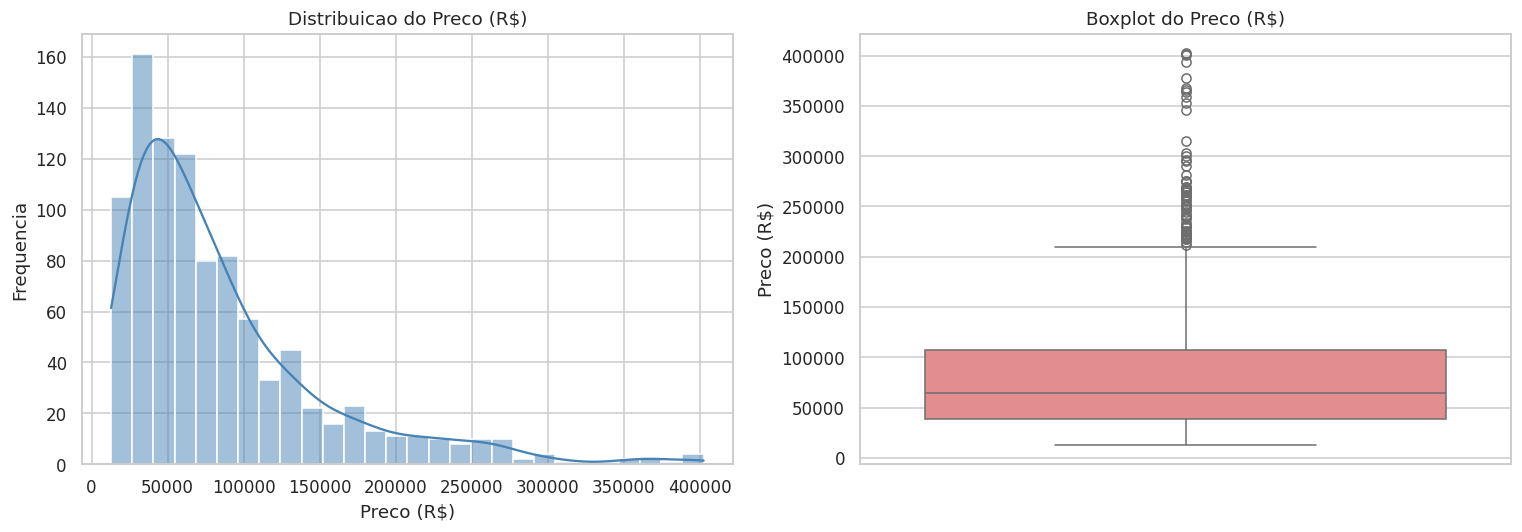

Assimetria (skewness): 1.84
Media: R$ 85,408.10  |  Mediana: R$ 64,097.45


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["valor"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribuicao do Preco (R$)")
axes[0].set_xlabel("Preco (R$)")
axes[0].set_ylabel("Frequencia")

sns.boxplot(y=df["valor"], ax=axes[1], color="lightcoral")
axes[1].set_title("Boxplot do Preco (R$)")
axes[1].set_ylabel("Preco (R$)")

plt.tight_layout()
plt.show()

print(f"Assimetria (skewness): {df['valor'].skew():.2f}")
print(f"Media: R$ {df['valor'].mean():,.2f}  |  Mediana: R$ {df['valor'].median():,.2f}")

### Matriz de correlacao

- `ano` tende a correlacao positiva: veiculos mais novos valem mais.
- `km` tende a correlacao negativa: mais rodado, menor valor.
- `potencia` correlacao positiva: motores maiores em veiculos premium.

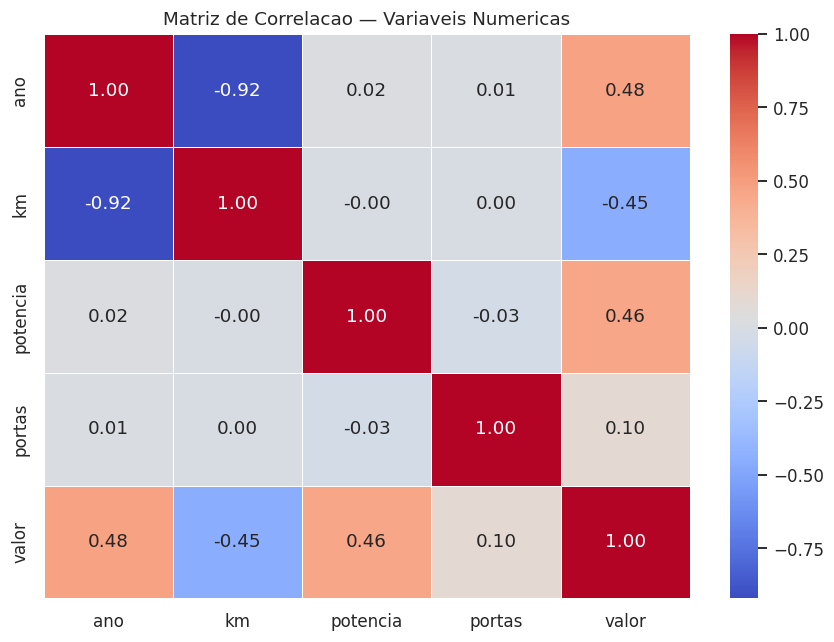

Correlacao com 'valor':
valor       1.00
ano         0.48
potencia    0.46
portas      0.10
km         -0.45
Name: valor, dtype: float64


In [14]:
corr = df[["ano", "km", "potencia", "portas", "valor"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlacao — Variaveis Numericas")
plt.tight_layout()
plt.show()

print("Correlacao com 'valor':")
print(corr["valor"].sort_values(ascending=False))

### Boxplots: preco por tipo, marca e cambio

- **Tipo:** Vans, SUVs e Pick-ups tendem a precos mais elevados; hatches e sedas sao mais acessiveis.
- **Marca:** BMW, Mercedes e Volvo lideram os precos medianos.
- **Cambio:** Veiculos automaticos apresentam precos significativamente maiores que os manuais.

/tmp/ipykernel_27523/1836041716.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="tipo", y="valor", order=ordem_tipo, ax=axes[0], palette="Set2")
/tmp/ipykernel_27523/1836041716.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="marca", y="valor", order=ordem_marca, ax=axes[1], palette="tab20")
/tmp/ipykernel_27523/1836041716.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="cambio", y="valor", ax=axes[2], palette="pastel")


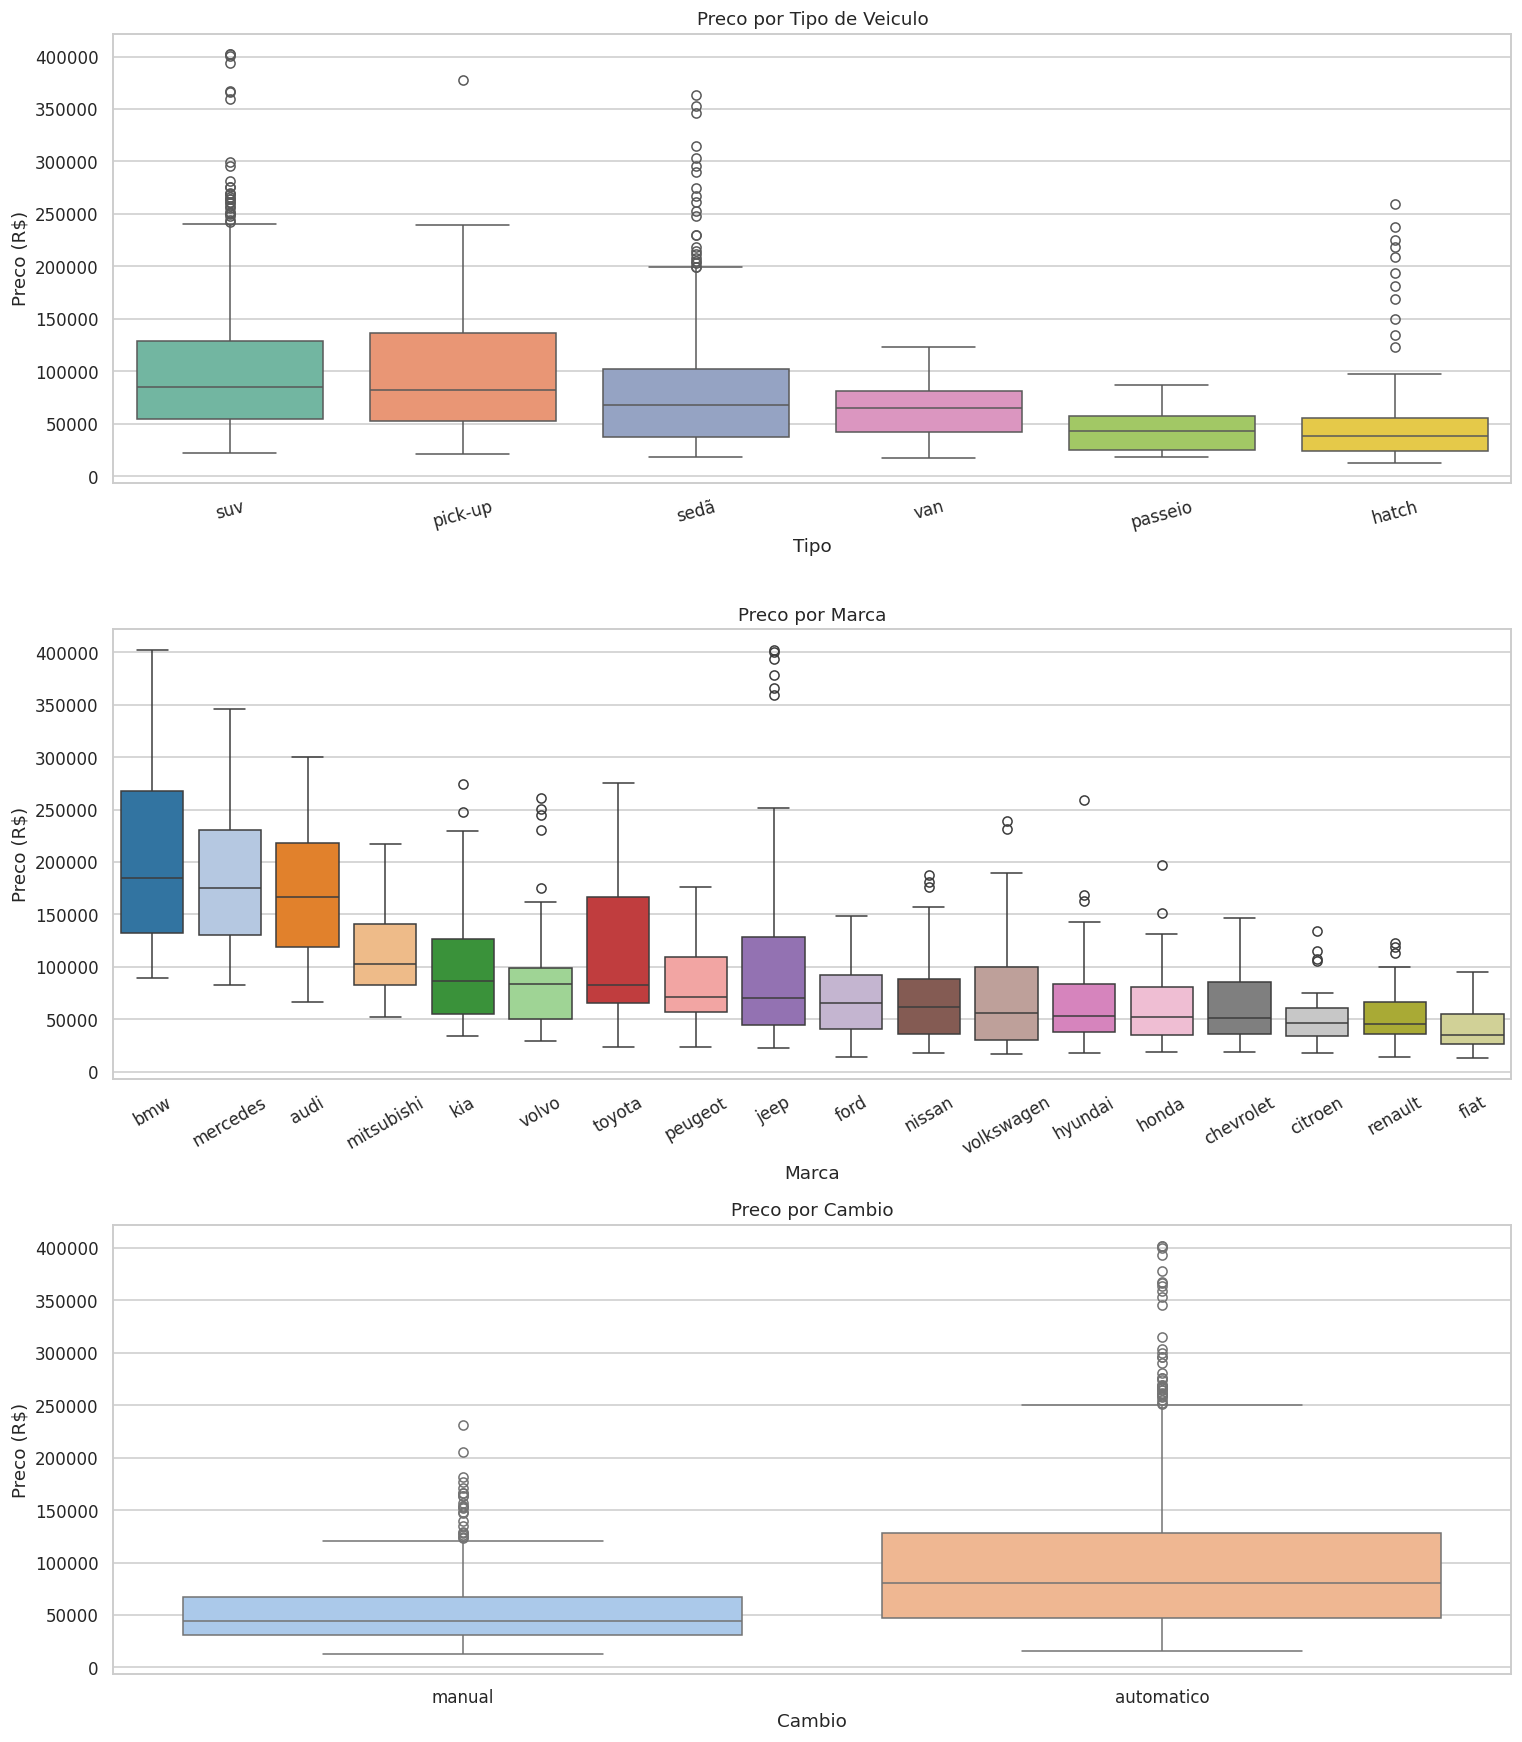

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(14, 16))

ordem_tipo = df.groupby("tipo")["valor"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="tipo", y="valor", order=ordem_tipo, ax=axes[0], palette="Set2")
axes[0].set_title("Preco por Tipo de Veiculo")
axes[0].set_xlabel("Tipo")
axes[0].set_ylabel("Preco (R$)")
axes[0].tick_params(axis="x", rotation=15)

ordem_marca = df.groupby("marca")["valor"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="marca", y="valor", order=ordem_marca, ax=axes[1], palette="tab20")
axes[1].set_title("Preco por Marca")
axes[1].set_xlabel("Marca")
axes[1].set_ylabel("Preco (R$)")
axes[1].tick_params(axis="x", rotation=30)

sns.boxplot(data=df, x="cambio", y="valor", ax=axes[2], palette="pastel")
axes[2].set_title("Preco por Cambio")
axes[2].set_xlabel("Cambio")
axes[2].set_ylabel("Preco (R$)")

plt.tight_layout()
plt.show()

### Scatter plots: km vs valor e ano vs valor

- `km` x `valor`: relacao negativa, mas com grande dispersao.
- `ano` x `valor`: relacao positiva, porem com nuvem ampla — veiculos do mesmo ano variam muito conforme marca e tipo.
Ambas as relacoes sugerem linearidade apenas aproximada.

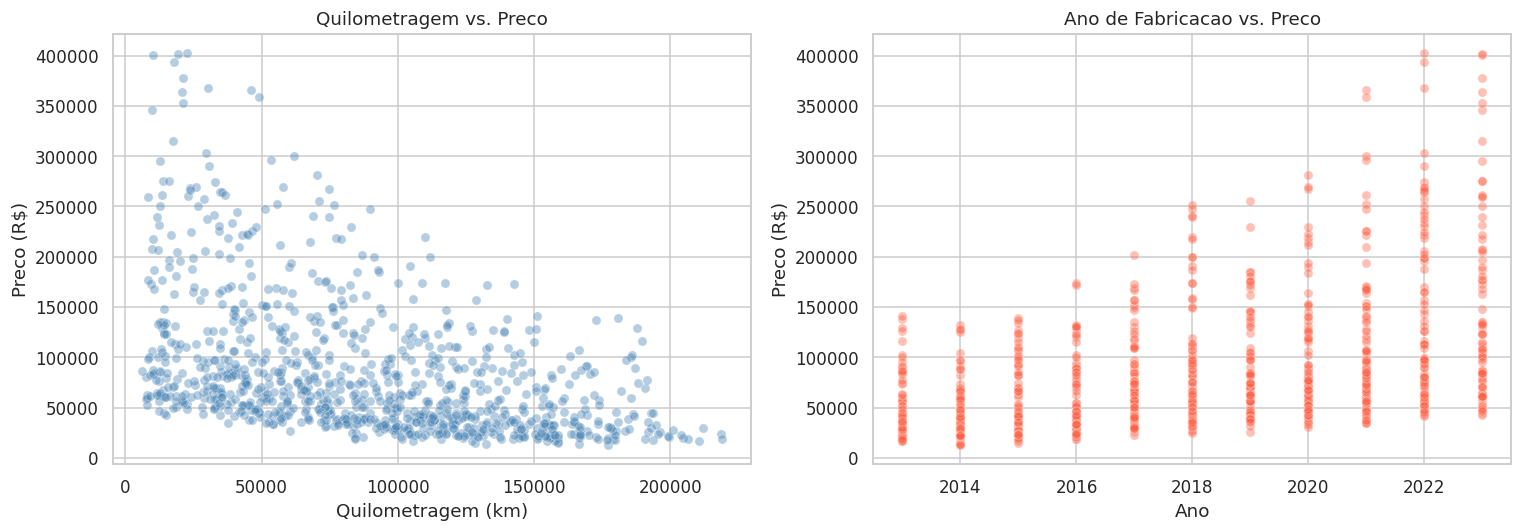

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x="km", y="valor", alpha=0.4, ax=axes[0], color="steelblue")
axes[0].set_title("Quilometragem vs. Preco")
axes[0].set_xlabel("Quilometragem (km)")
axes[0].set_ylabel("Preco (R$)")

sns.scatterplot(data=df, x="ano", y="valor", alpha=0.4, ax=axes[1], color="tomato")
axes[1].set_title("Ano de Fabricacao vs. Preco")
axes[1].set_xlabel("Ano")
axes[1].set_ylabel("Preco (R$)")

plt.tight_layout()
plt.show()

## 5.4 Pre-processamento

### Feature Engineering (Desafio Extra)

- `idade_veiculo = 2024 - ano` reflete depreciacao ao longo do tempo.
- `km_por_ano = km / idade_veiculo` indica intensidade de uso.

In [17]:
df["idade_veiculo"] = 2024 - df["ano"]

# Evitar divisao por zero (veiculo de 2024 -> idade = 0)
df["km_por_ano"] = df["km"] / df["idade_veiculo"].replace(0, np.nan)
df["km_por_ano"] = df["km_por_ano"].fillna(df["km_por_ano"].median())

print(df[["ano", "idade_veiculo", "km", "km_por_ano"]].head())

      ano  idade_veiculo       km  km_por_ano
0 2019.00           5.00 34055.00     6811.00
1 2020.00           4.00 40135.00    10033.75
2 2019.00           5.00 39184.00     7836.80
3 2020.00           4.00 28760.00     7190.00
4 2019.00           5.00 28600.00     5720.00


### Remocao da coluna `placa`

In [18]:
df = df.drop(columns=["placa"])
print("Colunas:", df.columns.tolist())

Colunas: ['modelo', 'marca', 'tipo', 'ano', 'km', 'potencia', 'combustivel', 'cambio', 'direcao', 'cor', 'portas', 'valor', 'idade_veiculo', 'km_por_ano']


### One-Hot Encoding

`drop_first=True` evita a dummy trap (multicolinearidade perfeita).

In [19]:
df_encoded = pd.get_dummies(df, drop_first=True)
print(f"Shape apos OHE: {df_encoded.shape}")
print(f"Numero de features (excluindo target): {df_encoded.shape[1] - 1}")

Shape apos OHE: (965, 117)
Numero de features (excluindo target): 116


### Separacao X e y

In [20]:
X = df_encoded.drop("valor", axis=1)
y = df_encoded["valor"]

print(f"X: {X.shape}  |  y: {y.shape}")

X: (965, 116)  |  y: (965,)


### Divisao treino/teste (80/20)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")

Treino: 772 amostras
Teste:  193 amostras


### Normalizacao com StandardScaler

`fit_transform` apenas no treino para evitar data leakage.

In [22]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Normalizacao aplicada.")

Normalizacao aplicada.


## 5.5 Treinamento do Modelo

In [23]:
modelo = LinearRegression()
modelo.fit(X_train_scaled, y_train)

y_pred       = modelo.predict(X_test_scaled)
y_pred_train = modelo.predict(X_train_scaled)

print("Modelo treinado.")

Modelo treinado.


### Coeficientes: top 5 positivos e top 5 negativos

Features positivas tipicamente incluem marcas premium, cambio automatico e motores maiores. Features negativas incluem alta quilometragem e veiculos antigos — coerente com o mercado.

In [24]:
coeficientes = pd.DataFrame({
    "Feature":     X.columns,
    "Coeficiente": modelo.coef_
}).sort_values("Coeficiente", ascending=False)

print("TOP 5 — aumentam o preco:")
print(coeficientes.head(5).to_string(index=False))

print("\nTOP 5 — reduzem o preco:")
print(coeficientes.tail(5).to_string(index=False))

TOP 5 — aumentam o preco:
        Feature  Coeficiente
      tipo_sedã     22218.45
modelo_wrangler     17033.84
      modelo_q5     13020.29
modelo_classe a     13018.73
      modelo_q3     12722.93

TOP 5 — reduzem o preco:
       Feature  Coeficiente
  modelo_versa     -7608.73
 modelo_fusion     -7761.42
 idade_veiculo     -9563.69
modelo_corolla     -9666.19
            km    -13400.53


### Grafico: Valores Reais vs. Preditos

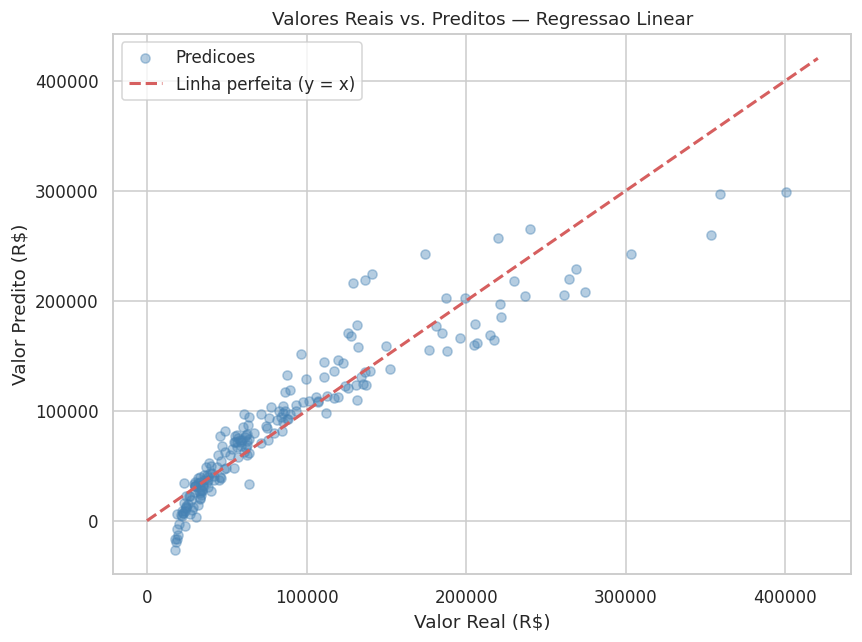

In [25]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color="steelblue", label="Predicoes")
lim = max(y_test.max(), y_pred.max()) * 1.05
plt.plot([0, lim], [0, lim], "r--", linewidth=2, label="Linha perfeita (y = x)")
plt.xlabel("Valor Real (R$)")
plt.ylabel("Valor Predito (R$)")
plt.title("Valores Reais vs. Preditos — Regressao Linear")
plt.legend()
plt.tight_layout()
plt.show()

## 5.6 Avaliacao do Modelo

In [26]:
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

n = X_test_scaled.shape[0]
p = X_test_scaled.shape[1]
r2_ajustado = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

r2_train    = r2_score(y_train, y_pred_train)

print("=" * 45)
print(f"  MAE          : R$ {mae:>12,.2f}")
print(f"  RMSE         : R$ {rmse:>12,.2f}")
print(f"  R2  (teste)  :    {r2:>12.4f}")
print(f"  R2  (treino) :    {r2_train:>12.4f}")
print(f"  R2 Ajustado  :    {r2_ajustado:>12.4f}")
print("=" * 45)
print(f"  Media preco  : R$ {y.mean():,.2f}")
print(f"  RMSE / Media : {rmse/y.mean()*100:.1f}%")

  MAE          : R$    18,203.93
  RMSE         : R$    25,955.75
  R2  (teste)  :          0.8707
  R2  (treino) :          0.8957
  R2 Ajustado  :          0.6733
  Media preco  : R$ 85,408.10
  RMSE / Media : 30.4%


### Analise de Residuos

O histograma deve ser aproximadamente normal e centrado em zero para que as premissas da regressao linear sejam atendidas. O grafico Residuo vs. Predito deve mostrar pontos dispersos sem padrao — padrao em funil indicaria heteroscedasticidade.

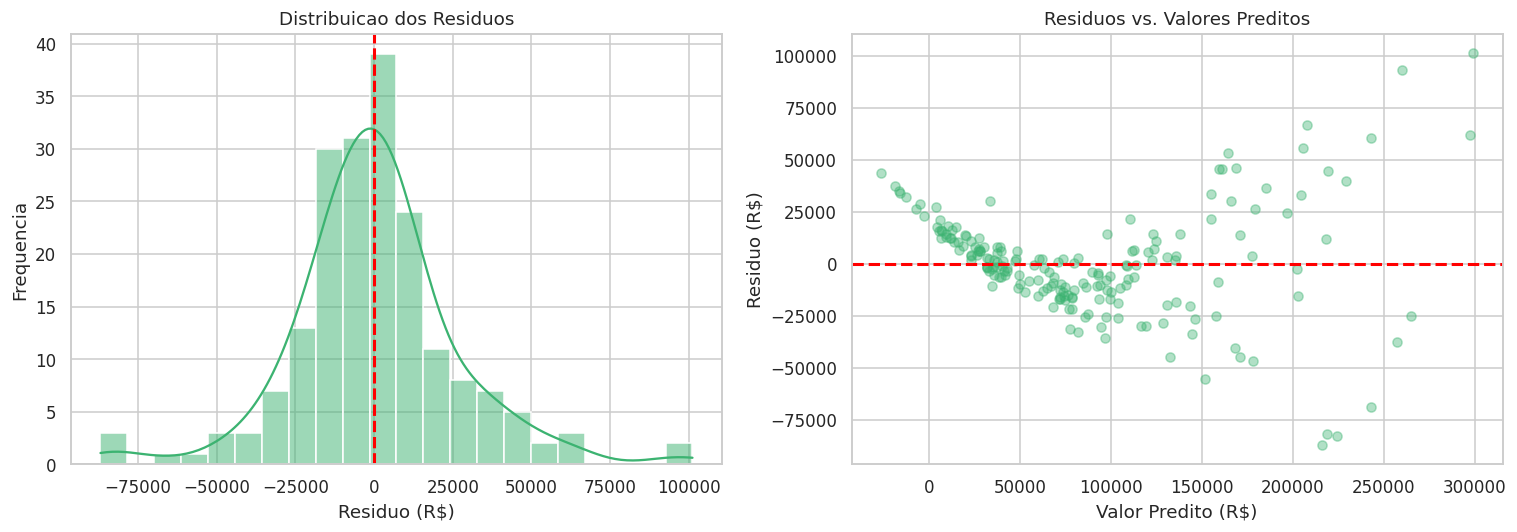

Media dos residuos : R$ 272.18  (ideal: proximo de 0)
Assimetria         : 0.214        (ideal: proximo de 0)


In [27]:
residuos = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(residuos, kde=True, ax=axes[0], color="mediumseagreen")
axes[0].axvline(0, color="red", linestyle="--", linewidth=2)
axes[0].set_title("Distribuicao dos Residuos")
axes[0].set_xlabel("Residuo (R$)")
axes[0].set_ylabel("Frequencia")

axes[1].scatter(y_pred, residuos, alpha=0.4, color="mediumseagreen")
axes[1].axhline(0, color="red", linestyle="--", linewidth=2)
axes[1].set_title("Residuos vs. Valores Preditos")
axes[1].set_xlabel("Valor Predito (R$)")
axes[1].set_ylabel("Residuo (R$)")

plt.tight_layout()
plt.show()

print(f"Media dos residuos : R$ {residuos.mean():.2f}  (ideal: proximo de 0)")
print(f"Assimetria         : {residuos.skew():.3f}        (ideal: proximo de 0)")

### Validacao Cruzada (10 folds)

Desvio padrao baixo entre os folds indica modelo estavel e que nao depende de uma particao especifica dos dados.

In [28]:
scores_cv = cross_val_score(
    LinearRegression(),
    X_train_scaled,
    y_train,
    cv=10,
    scoring="neg_root_mean_squared_error"
)

rmse_cv = -scores_cv

for i, v in enumerate(rmse_cv, 1):
    print(f"  Fold {i:2d}: R$ {v:,.2f}")

print(f"\nMedia RMSE CV  : R$ {rmse_cv.mean():,.2f}")
print(f"Desvio Padrao  : R$ {rmse_cv.std():,.2f}")

  Fold  1: R$ 30,095.49
  Fold  2: R$ 25,410.20
  Fold  3: R$ 25,074.88
  Fold  4: R$ 29,861.38
  Fold  5: R$ 22,506.38
  Fold  6: R$ 20,967.88
  Fold  7: R$ 23,675.09
  Fold  8: R$ 27,281.20
  Fold  9: R$ 22,772.79
  Fold 10: R$ 23,118.24

Media RMSE CV  : R$ 25,076.35
Desvio Padrao  : R$ 2,960.57


## 5.7 Analise e Discussao

### a) Overfitting ou underfitting?

In [29]:
print(f"R2 Treino: {r2_train:.4f}")
print(f"R2 Teste : {r2:.4f}")
print(f"Diferenca: {abs(r2_train - r2):.4f}")

if r2_train - r2 > 0.05:
    print("\n-> Diferenca > 0.05: indicio de OVERFITTING (modelo memorizou o treino)")
elif r2 < 0.6:
    print("\n-> R2 baixo em ambos: indicio de UNDERFITTING (modelo muito simples)")
else:
    print("\n-> Diferenca pequena e R2 razoavel: boa generalizacao")

R2 Treino: 0.8957
R2 Teste : 0.8707
Diferenca: 0.0250

-> Diferenca pequena e R2 razoavel: boa generalizacao


### b) A relacao entre km, ano e preco e verdadeiramente linear?

O grafico de dispersao e o grafico de residuos indicam:
- `km` x `valor`: relacao negativa com alta dispersao — nao e estritamente linear.
- `ano` x `valor`: relacao positiva, mas com nuvem ampla — veiculos do mesmo ano variam muito conforme marca.
- O grafico de residuos vs. preditos mostra padrao de funil crescente, evidenciando que a linearidade e apenas aproximada e que uma transformacao logaritmica no target poderia melhorar o ajuste.

### c) Impacto dos erros no dataset sobre o desempenho

| Tipo de Problema | Impacto |
|---|---|
| Valores nulos | Preenchimento com mediana/moda e conservador mas pode introduzir vies |
| Erros de digitacao | Criam categorias fantasmas no OHE, inflando dimensionalidade e reduzindo qualidade |
| Valores fora do dominio | Outliers extremos distorcem os coeficientes OLS — um unico preco absurdo degrada o modelo |
| Inconsistencias logicas | Introduzem ruido que o modelo tenta aprender, reduzindo R2 e aumentando RMSE |

### d) OHE com muitas colunas e um problema? Como Ridge/Lasso ajudam?

Ao aplicar OHE em `marca` e `modelo`, geramos dezenas de colunas binarias, causando:
1. Alta dimensionalidade — risco de overfitting
2. Multicolinearidade parcial — coeficientes instaveis
3. Esparsidade — cada linha tem poucos 1s entre muitas colunas

**Ridge (L2):** penaliza coeficientes grandes, encolhendo todos e estabilizando estimativas.

**Lasso (L1):** zera coeficientes irrelevantes, funcionando como selecao automatica de features.

### e) Propostas de melhoria

1. **Transformacao logaritmica do target:** `np.log(valor)` lineariza a distribuicao assimetrica, reduzindo o impacto de outliers.
2. **Regularizacao Ridge ou Lasso:** controla overfitting causado pelo alto numero de dummies e estabiliza coeficientes.

## 6. Desafio Extra

### Modelo com Transformacao Logaritmica no Target

In [30]:
y_log = np.log(y)

X_train_e, X_test_e, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

scaler_e = StandardScaler()
X_train_e_sc = scaler_e.fit_transform(X_train_e)
X_test_e_sc  = scaler_e.transform(X_test_e)

modelo_log = LinearRegression()
modelo_log.fit(X_train_e_sc, y_train_log)

y_pred_log_orig = np.exp(modelo_log.predict(X_test_e_sc))
y_test_orig     = np.exp(y_test_log)

rmse_log = np.sqrt(mean_squared_error(y_test_orig, y_pred_log_orig))
r2_log   = r2_score(y_test_orig, y_pred_log_orig)

print(f"{'Modelo':<28} {'RMSE (R$)':>15} {'R2':>8}")
print("-" * 53)
print(f"{'Linear (target original)':<28} {rmse:>15,.2f} {r2:>8.4f}")
print(f"{'Linear (log do target)':<28} {rmse_log:>15,.2f} {r2_log:>8.4f}")

Modelo                             RMSE (R$)       R2
-----------------------------------------------------
Linear (target original)           25,955.75   0.8707
Linear (log do target)              7,210.56   0.9900


### Ridge Regression com GridSearchCV

In [31]:
param_grid = {"alpha": [0.01, 0.1, 1, 10, 100, 1000]}

ridge_cv = GridSearchCV(
    Ridge(),
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
ridge_cv.fit(X_train_scaled, y_train)

melhor_alpha = ridge_cv.best_params_["alpha"]
melhor_ridge = ridge_cv.best_estimator_

y_pred_ridge = melhor_ridge.predict(X_test_scaled)
rmse_ridge   = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge     = r2_score(y_test, y_pred_ridge)

print(f"Melhor alpha Ridge: {melhor_alpha}")
print(f"\n{'Modelo':<22} {'RMSE (R$)':>15} {'R2':>8}")
print("-" * 47)
print(f"{'Linear':<22} {rmse:>15,.2f} {r2:>8.4f}")
print(f"{'Ridge':<22} {rmse_ridge:>15,.2f} {r2_ridge:>8.4f}")

Melhor alpha Ridge: 10

Modelo                       RMSE (R$)       R2
-----------------------------------------------
Linear                       25,955.75   0.8707
Ridge                        25,613.45   0.8741


### Lasso Regression — Selecao Automatica de Features

O Lasso com L1 zera features redundantes, funcionando como seletor automatico. Features zeradas sao aquelas que nao contribuem significativamente para a predicao do preco.

In [32]:
lasso_cv = GridSearchCV(
    Lasso(max_iter=10_000),
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
lasso_cv.fit(X_train_scaled, y_train)

melhor_lasso = lasso_cv.best_estimator_

y_pred_lasso = melhor_lasso.predict(X_test_scaled)
rmse_lasso   = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso     = r2_score(y_test, y_pred_lasso)

n_zeros = (melhor_lasso.coef_ == 0).sum()
n_total = len(melhor_lasso.coef_)

print(f"Melhor alpha Lasso: {lasso_cv.best_params_['alpha']}")
print(f"Features zeradas: {n_zeros} de {n_total} ({n_zeros/n_total*100:.1f}%)")
print(f"\n{'Modelo':<22} {'RMSE (R$)':>15} {'R2':>8}")
print("-" * 47)
print(f"{'Linear':<22} {rmse:>15,.2f} {r2:>8.4f}")
print(f"{'Ridge':<22} {rmse_ridge:>15,.2f} {r2_ridge:>8.4f}")
print(f"{'Lasso':<22} {rmse_lasso:>15,.2f} {r2_lasso:>8.4f}")

Melhor alpha Lasso: 0.01
Features zeradas: 2 de 116 (1.7%)

Modelo                       RMSE (R$)       R2
-----------------------------------------------
Linear                       25,955.75   0.8707
Ridge                        25,613.45   0.8741
Lasso                        25,929.63   0.8709


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.189e+10, tolerance: 3.352e+08
  model = cd_fast.enet_coordinate_descent(


## Conclusao Geral

Este notebook cobriu todas as etapas de um pipeline de Machine Learning supervisionado:

1. Inspecao e compreensao dos dados — identificacao de tipos, nulos e anomalias
2. Limpeza robusta — tratamento de 4 categorias de erros
3. EDA — visualizacoes que revelam padroes e motivam decisoes de modelagem
4. Feature Engineering — criacao de features derivadas mais informativas
5. Pre-processamento — OHE, normalizacao e divisao treino/teste sem data leakage
6. Modelagem — Regressao Linear treinada e avaliada com metricas completas
7. Analise critica — interpretacao dos resultados e propostas de melhoria
8. Modelos avancados — Ridge e Lasso para regularizacao; log-transform do target